In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display Settings to display all columns
pd.set_option('display.max_columns', None)

In [4]:
# Load the dataset
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
# Check the number of rows and columns and meta data information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 33
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Ser

We have 7043 rows and 33 columns in the dataset. There are few columns that are not required for the analysis. We will inspect the data types of the columns to understand the data better and further inspect the data for any missing values, outliers and inconsistencies and will handle them accordingly.

In [8]:
# Trim spaces, lowercase, and replace internal spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
# Check for the data types
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})
data_types

,Column,Data Type
0,customerid,str
1,count,int64
2,country,str
3,state,str
4,city,str
5,zip_code,int64
6,lat_long,str
7,latitude,float64
8,longitude,float64
9,gender,str


In [10]:
# Almost all the columns have correct data types. The only issue is that the TotalCharges column is an object type. We will convert it to a float.
# Rest of the columns we can keep as is for now for understanding the data better and will handle them later during the data cleaning process.

df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [11]:
# Check for duplicates and remove them
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [12]:
# Check for statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
zip_code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
tenure_months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
monthly_charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
total_charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
churn_value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
churn_score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
cltv,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


- In total there are **7043** *rows* and **33** *columns* in the dataset.
- There are **11** *missing values* in the *TotalCharges* column and we need to handle them.
- There is a massive *positive skewness* in the *TotalCharges* column i.e. a long tail on the right side of the distribution having small groups of customers with high charges.
- There is an **imbalance** in the dataset as the mean of churn_value is 0.265370 which is *26.5% of the customers churned*.
- Customer *tenure ranges* from *0 to 72 months* i.e. from a brand new customer to a customer who has been with the company for 6 years.
- There is a slight *negative skewness* in the *monthly_charges* column, which depicts that there are few customers with very high monthly charges and large chunk of customers have low monthly charges.

In [19]:
# Remove the columns that are not required for the analysis
remove_columns = [
    'count', # It is always 1
    'country', # We have only one country
    'state', # We have only one state
    'churn_reason', # It is not required for the analysis
    'lat_long' # Redundant column
]

df.drop(columns=remove_columns, inplace=True)

print(df.shape)

KeyError: "['count', 'country', 'state', 'churn_reason'] not found in axis"

In [17]:
df.head()

,customerid,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340


In [21]:
# Check for missing values
df.isnull().sum()

customerid            0
city                  0
zip_code              0
lat_long              0
latitude              0
longitude             0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure_months         0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn_label           0
churn_value           0
churn_score           0
cltv                  0
dtype: int64

For **total_charges** column, we have **11 missing values**. Most of the customers have current tenure as 0 months i.e. they are *brand new customers* and have a valid tenure. So, we can *impute* the missing values *with the current monthly charges*.

In [26]:
# Impute the missing values with the current monthly charges
df['total_charges'] = df['total_charges'].fillna(df['monthly_charges'])
print(df.isnull().sum())

customerid           0
city                 0
zip_code             0
lat_long             0
latitude             0
longitude            0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn_label          0
churn_value          0
churn_score          0
cltv                 0
dtype: int64


In [ ]:
# Check for outliers
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col,count])

outliers = pd.DataFrame(outlier_summary, columns=['Feature','Outliers'])

outliers.sort_values(by='Outliers', ascending=False)

,Feature,Outliers
0,zip_code,0
1,latitude,0
2,longitude,0
3,tenure_months,0
4,monthly_charges,0
5,total_charges,0
6,churn_value,0
7,churn_score,0
8,cltv,0


There are no outliers in the data set

### Feature Engineering

In [34]:
# Tenure Groups
def categorize_tenure(months):
    if months <= 12:
        return '0-1 Year'
    elif months <= 24:
        return '1-2 Years'
    elif months <= 48:
        return '2-4 Years'
    else:
        return '4+ Years'

df['tenure_group'] = df['tenure_months'].apply(categorize_tenure)
df.head()

,customerid,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,tenure_group
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,0-1 Year
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,0-1 Year
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,0-1 Year
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,2-4 Years
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,4+ Years


In [36]:
# Average monthly usage
df['avg_monthly_usage'] = np.where(
    df['monthly_charges'] > 0,
    df['total_charges'] / df['tenure_months'],
    df['monthly_charges']
)
df.head()

,customerid,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,tenure_group,avg_monthly_usage
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,0-1 Year,54.075000
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,0-1 Year,75.825000
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,0-1 Year,102.562500
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,2-4 Years,108.787500
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,4+ Years,102.781633


In [38]:
# Payment risk category
risk_map = {
    'Electronic check'          : 'High Risk',
    'Mailed check'              : 'Medium Risk',
    'Bank transfer (automatic)' : 'Low Risk',
    'Credit card (automatic)'   : 'Low Risk'
}
df['payment_risk'] = df['payment_method'].map(risk_map)

In [40]:
# Customer Value Segment
df['customer_value_segment'] = pd.qcut(
    df['cltv'],
    q=4,
    labels=[
        'Bronze',
        'Silver',
        'Gold',
        'Platinum'
    ]
)

In [47]:
# number of services used
service_columns = [
    'phone_service', 'multiple_lines', 'internet_service', 
    'online_security', 'online_backup', 'device_protection', 
    'tech_support', 'streaming_tv', 'streaming_movies'
]

df['total_services'] = 0

for col in service_columns:
    if col == 'internet_service':

        df['total_services'] += df[col].isin(['DSL', 'Fiber optic']).astype(int)
    else:
        df['total_services'] += (df[col] == 'Yes').astype(int)


In [54]:
df.head()

,customerid,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,tenure_group,avg_monthly_usage,payment_risk,customer_value_segment,total_services
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,0-1 Year,54.075000,Medium Risk,Bronze,4
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,0-1 Year,75.825000,High Risk,Bronze,2
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,0-1 Year,102.562500,High Risk,Gold,6
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,2-4 Years,108.787500,High Risk,Gold,7
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,4+ Years,102.781633,Low Risk,Gold,7


### Exploratory Analysis

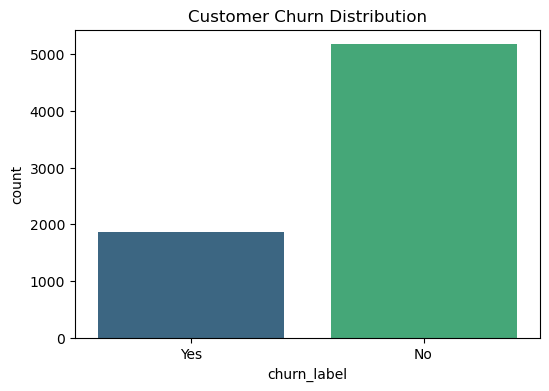

In [62]:
# Customer churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn_label', palette='viridis')
plt.title('Customer Churn Distribution')
plt.show()

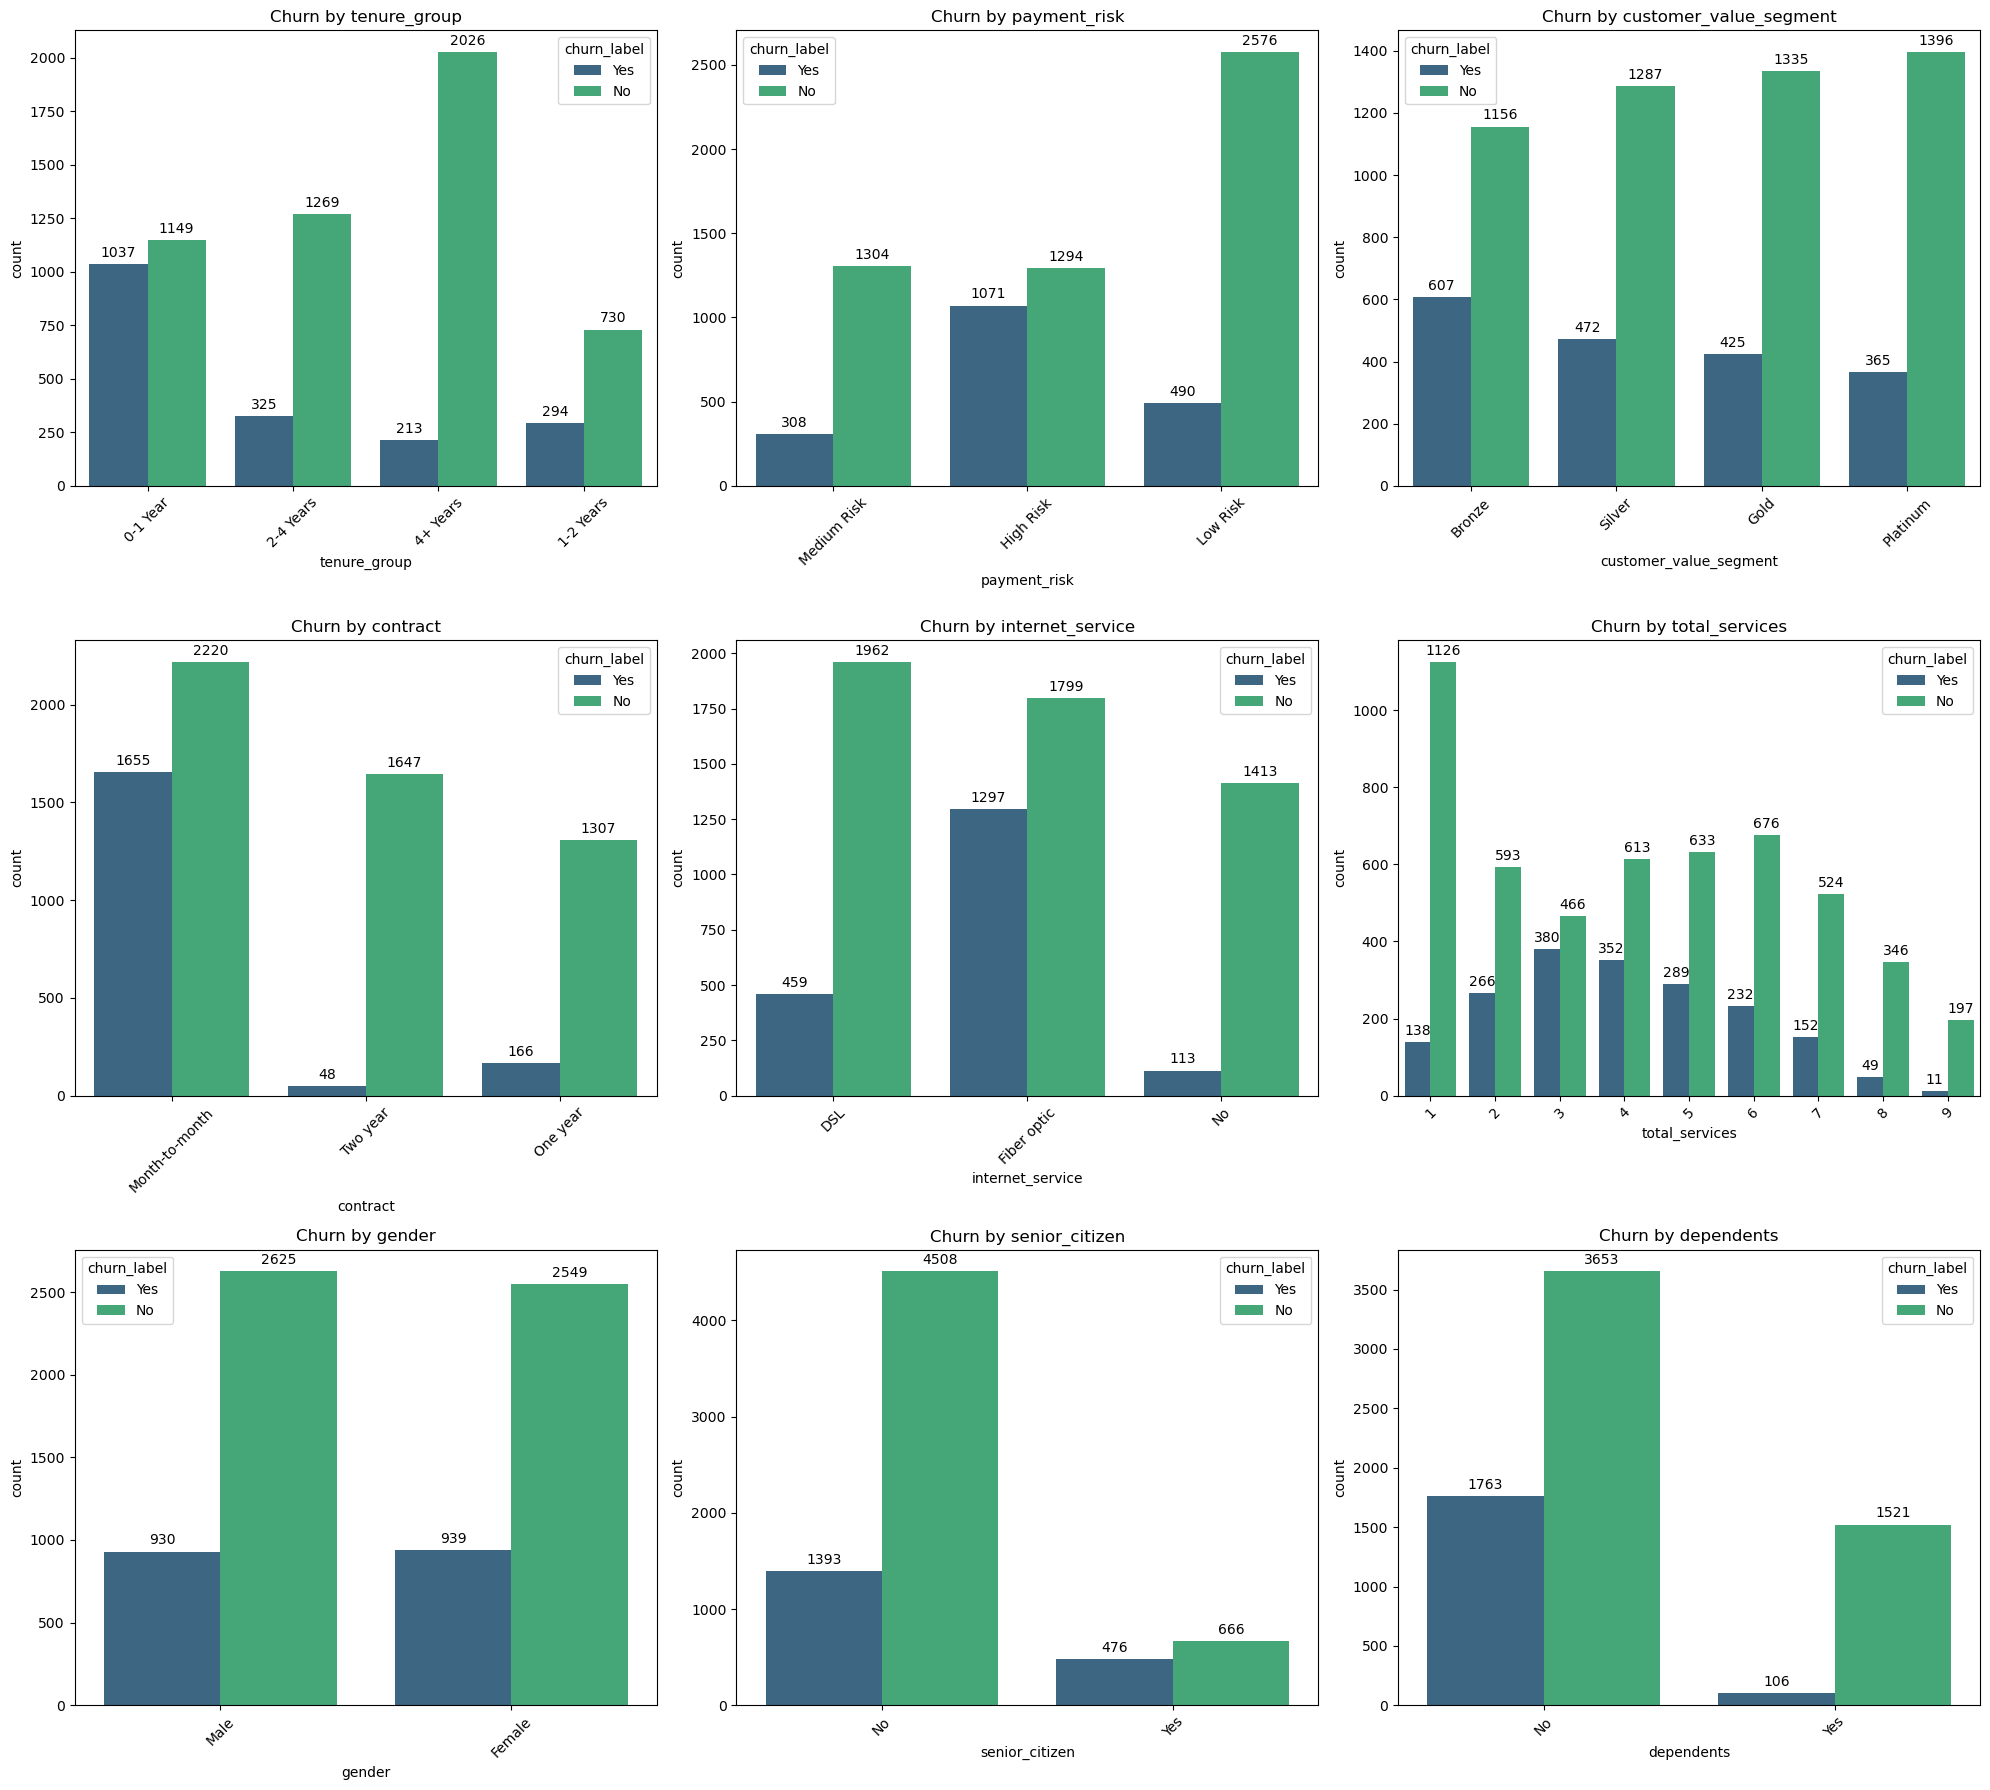

In [73]:
categorical_cols = ['tenure_group', 'payment_risk', 'customer_value_segment', 
                    'contract', 'internet_service', 'total_services', 
                    'gender', 'senior_citizen', 'dependents']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    sns.countplot(data=df, x=col, hue='churn_label', ax=ax, palette='viridis')
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)


plt.tight_layout()
plt.show()

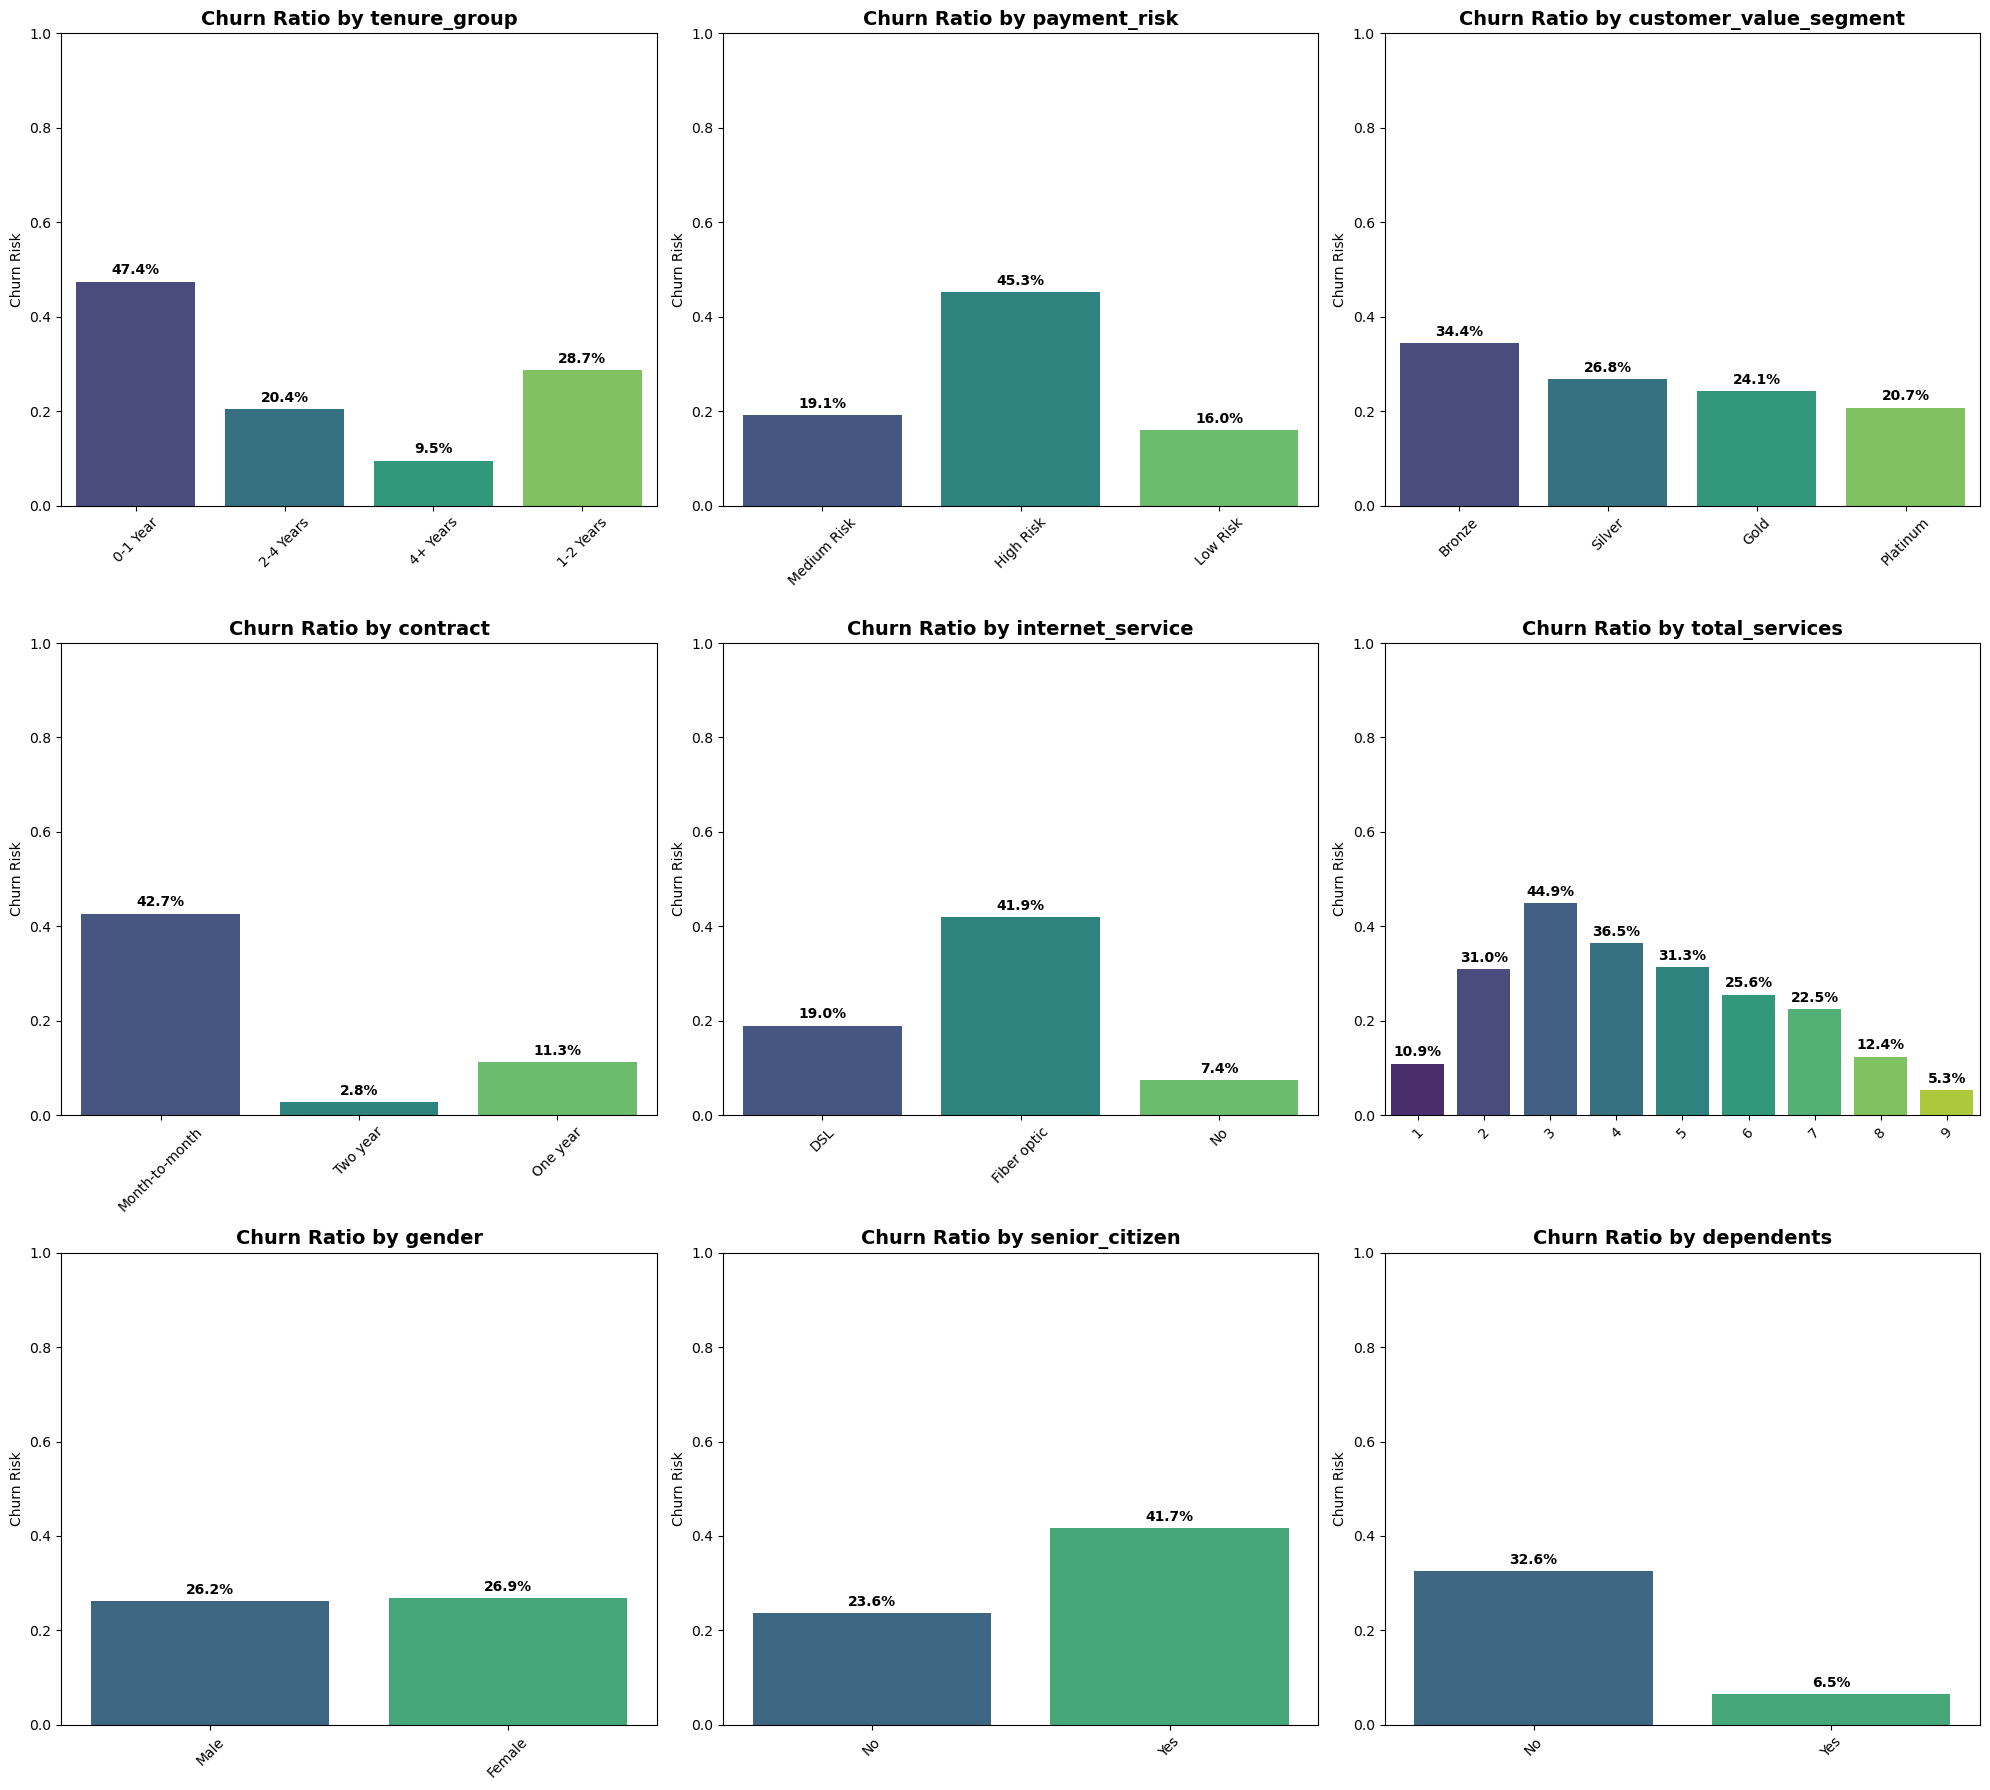

In [78]:

if 'churn_numeric' not in df.columns:
    df['churn_numeric'] = df['churn_label'].map({'Yes': 1, 'No': 0})

categorical_cols = ['tenure_group', 'payment_risk', 'customer_value_segment', 
                    'contract', 'internet_service', 'total_services', 
                    'gender', 'senior_citizen', 'dependents']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
   
    sns.barplot(data=df, x=col, y='churn_numeric', ax=ax, palette='viridis', errorbar=None)
    
    ax.set_title(f'Churn Ratio by {col}', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Churn Risk')
    ax.set_xlabel('')
    
    ax.set_ylim(0, 1)

   
    for container in ax.containers:

        labels = [f"{(bar.get_height() * 100):.1f}%" for bar in container]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

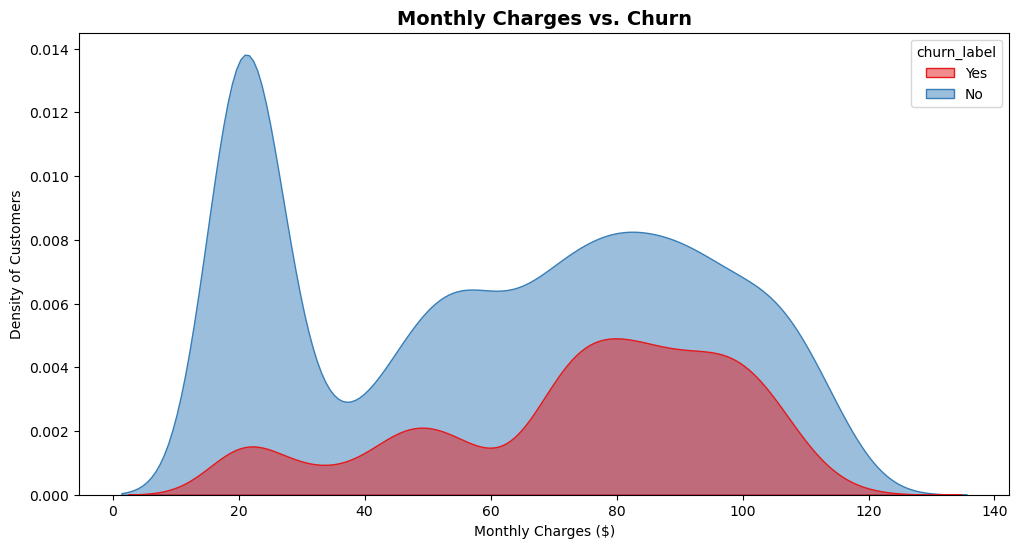

In [85]:
# Monthly Charge vs churn
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df, 
    x='monthly_charges', 
    hue='churn_label', 
    fill=True, 
    palette='Set1', 
    alpha=0.5
)

plt.title('Monthly Charges vs. Churn', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density of Customers')

plt.show()